In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.dimensionality import BaseDimensionalityReduction
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
import torch
from wordcloud import WordCloud

f:\UI\Semester 8\Tugas Akhir\topic-modelling\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
indo_stopwords = [
    # Basic Indonesian stopwords (keep these)
    "yang", "dan", "di", "dengan", "untuk", "dari", "ke", "pada", "ini", "itu",
    "atau", "ada", "juga", "dalam", "saya", "kamu", "anda", "mereka", "kita", "kami",
    "dia", "nya", "adalah", "akan", "oleh", "seperti", "telah", "sudah", "bisa", "dapat",
    "tidak", "tak", "jangan", "ya", "via", "yg", "dgn", "utk", "dr", "pd", "dlm", "sdh", "tdk",
    "tapi", "aku","gini","begini", "kayak"
    
    # All candidate names and variations (since they appear everywhere)
    "anies", "baswedan", "rasyid", "muhaimin", "iskandar", "cak", "imin", "gus", 
    "prabowo", "subianto", "gibran", "rakabuming", "raka", "ganjar", "pranowo", 
    "mahfud", "md", "gama", "mawi", "abdurrahman", "abdul", "amin"
    
    # Titles and name prefixes
    "mas", "pak", "bu", "bapak", "ibu", "om", "tante", "mbak", "bro", "sis", "bang", 
    "abang", "kak", "adek", "adik", "kakak", "bung", "prof", "dr", "haji", "hajah", "h",
    
    # Social media expressions
    "rt", "dm", "pm", "cc", "wkwk", "haha", "woi", "hey", "ah", "eh", "oh", "hmm", "btw",
    "omg", "lol", "sih", "aja", "gitu", "banget", "kok", "deh", "ih", "yuk", "mantap",
    "insya", "insyaallah", "alhamdulillah", "bismillah", "amin", "allahuma", "allah",
    
    # Locations
    "jakarta", "jawa", "barat", "timur", "tengah", "utara", "selatan", "sumatra", "bali", 
    "aceh", "kota", "desa", "daerah", "wilayah", "provinsi", "kabupaten", "kawasan",
    "bandung", "surabaya", "makassar", "balikpapan", "semarang", "yogyakarta", "solo", "korea"
    
]

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [4]:
def run_topic_modeling(df, group_name='ALL'):
     # Set up custom vectorizer
    vectorizer = CountVectorizer(
        stop_words=indo_stopwords,
        ngram_range=(1, 3),
        min_df=5,
        max_df=0.7
    )

    # Set up UMAP
    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric='cosine',
        random_state=42
    )

    # Set up HDBSCAN
    hdbscan_model = HDBSCAN(
        min_cluster_size=10,
        min_samples=5,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )

    # Set up c-TF-IDF
    ctfidf_model = ClassTfidfTransformer(
        reduce_frequent_words=True,
        bm25_weighting=True
    )

    # Sentence embeddings
    embedding_model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

    # BERTopic setup
    topic_model = BERTopic(
        language="multilingual",
        calculate_probabilities=True,
        verbose=True,
        nr_topics=15,
        min_topic_size=5,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        ctfidf_model=ctfidf_model,
        vectorizer_model=vectorizer,
        embedding_model=embedding_model
    )

    # Fit model
    docs = df['full_text'].tolist()
    topics, probs = topic_model.fit_transform(docs)
    
    # Generate custom topic labels
    topic_labels = {}
    for topic_id in topic_model.get_topic_info()["Topic"]:
        if topic_id == -1:
            topic_labels[topic_id] = "outlier"
            continue
        words = [word for word, _ in topic_model.get_topic(topic_id)[:5]]
        if any(term in words for term in ["bal", "bali", "rahajeng", "rawuh"]):
            topic_labels[topic_id] = "Kampanye Bali"
        elif any(term in words for term in ["jawa", "tengah", "jateng", "banteng"]):
            topic_labels[topic_id] = "Basis Dukungan Jawa Tengah"
        elif any(term in words for term in ["legislatif", "eksekutif", "yudikatif", "jejak", "rekam"]):
            topic_labels[topic_id] = "Pengalaman Pemerintahan"
        elif any(term in words for term in ["fokus", "dukung", "motivasi", "kembang"]):
            topic_labels[topic_id] = "Dukungan & Motivasi"
        elif any(term in words for term in ["demokrasi", "partai", "pdip", "banteng", "merah"]):
            topic_labels[topic_id] = "Dukungan Partai PDI-P"
        elif any(term in words for term in ["dame", "hati", "adem", "damai", "sejuk"]):
            topic_labels[topic_id] = "Citra Kepemimpinan Adem"
        elif any(term in words for term in ["aspirasi", "dengar", "blusuk", "jumpa"]):
            topic_labels[topic_id] = "Pendekatan ke Masyarakat"
        elif any(term in words for term in ["tegak", "lurus", "jujur", "bersih"]):
            topic_labels[topic_id] = "Integritas & Kejujuran"
        elif any(term in words for term in ["huru", "hara", "politik", "sembuh", "luka"]):
            topic_labels[topic_id] = "Perbaikan Situasi Politik"
        elif any(term in words for term in ["penjuru", "nusantara", "kenal"]):
            topic_labels[topic_id] = "Popularitas Nasional"
        else:
            # Use the first few words as a generic label
            topic_labels[topic_id] = " & ".join(words[:3])
    topic_model.set_topic_labels(topic_labels)

    # Topic info
    topic_info = topic_model.get_topic_info()
    print(f"\nTopic Information for: {group_name}")
    print(topic_info.head(10))

    # Print topic summaries
    print(f"\nTopik Pembicaraan Masyarakat terhadap Calon Ganjar-Mahfud ({group_name}):")
    for index, row in topic_info.iterrows():
        if row["Topic"] != -1:
            topic_id = row["Topic"]
            words = [word[0] for word in topic_model.get_topic(topic_id)[:8]]
            print(f"Theme: {row['Name']}")
            print(f"Keywords: {', '.join(words)}")
            print(f"Document count: {row['Count']}")
            print("-" * 50)

    # Bar chart of topic distribution
    plt.figure(figsize=(12, 6))
    topic_counts = topic_info[topic_info["Topic"] != -1]["Count"]
    topic_names = [topic_labels[topic] for topic in topic_info[topic_info["Topic"] != -1]["Topic"]]

    bars = plt.bar(topic_names, topic_counts, color=plt.cm.viridis(np.linspace(0, 1, len(topic_counts))))
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

    plt.xticks(rotation=45, ha="right")
    plt.title(f"Distribusi Topik: {group_name}", fontsize=14, fontweight='bold')
    plt.xlabel("Topik Pembicaraan", fontsize=12)
    plt.ylabel("Jumlah Tweet", fontsize=12)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Interactive Visualizations
    display(topic_model.visualize_topics())
    display(topic_model.visualize_hierarchy())
    display(topic_model.visualize_heatmap())

    # Word Clouds for top 3 topics
    plt.figure(figsize=(15, 10))
    for i, topic_id in enumerate(topic_info[topic_info['Topic'] != -1]['Topic'][:3]):
        plt.subplot(1, 3, i+1)
        words = dict(topic_model.get_topic(topic_id)[:15])
        wordcloud = WordCloud(width=400, height=400, background_color='white',
                              colormap='viridis', max_words=50).generate_from_frequencies(words)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f"Topic: {topic_labels[topic_id]}", fontsize=12)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Representative sentences per topic
    print(f"\nKalimat Representatif untuk Setiap Topik ({group_name}):")
    rep_docs = topic_model.get_representative_docs()
    rows = []
    for topic_id, texts in rep_docs.items():
        if topic_id == -1:
            continue
        rows.append({
            "Topic ID": topic_id,
            "Label": topic_labels[topic_id],
            "Representative Sentence": texts[0]  # You can use texts[:3] for more
        })
    rep_df = pd.DataFrame(rows)
    display(rep_df)

    return topic_model, topics, probs

In [5]:
df_03 = pd.read_csv('data/03_full_context_pred.csv')

2025-05-26 21:01:27,871 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 1183/1183 [07:51<00:00,  2.51it/s]
2025-05-26 21:09:20,577 - BERTopic - Embedding - Completed ✓
2025-05-26 21:09:20,579 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-26 21:10:09,561 - BERTopic - Dimensionality - Completed ✓
2025-05-26 21:10:09,562 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 21:31:18,966 - BERTopic - Cluster - Completed ✓
2025-05-26 21:31:18,967 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-05-26 21:31:21,174 - BERTopic - Representation - Completed ✓
2025-05-26 21:31:21,175 - BERTopic - Topic reduction - Reducing number of topics
2025-05-26 21:31:21,217 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 21:31:22,784 - BERTopic - Representation - Completed ✓
2025-05-26 21:31:22,789 - BERTopic - Topic reduction - 


Topic Information for: POSITIVE
   Topic  Count                                               Name  \
0     -1  12002                        -1_m3nang_tetap_benar_anies   
1      0  19511                0_sejahtera_demokrasi_merakyat_muda   
2      1   2376              1_paslon 03_paslon_pilih 03_dukung 03   
3      2   1392                       2_all in_gaspol_gaspoll_gass   
4      3    778      3_program_unggulan_melalui program_bermanfaat   
5      4    557               4_ekonomi_lokal_produk_infrastruktur   
6      5    503  5_debat_juara_hebat debat_ganjarbersih kuatkan...   
7      6    320          6_internet_gratis_internet gratis_program   
8      7    107                  7_kaum_peduli_teman_selalu peduli   
9      8     95             8_digital_era_internet_internet gratis   

                             CustomName  \
0                               outlier   
1                 Dukungan Partai PDI-P   
2         paslon 03 & paslon & pilih 03   
3             all in & g

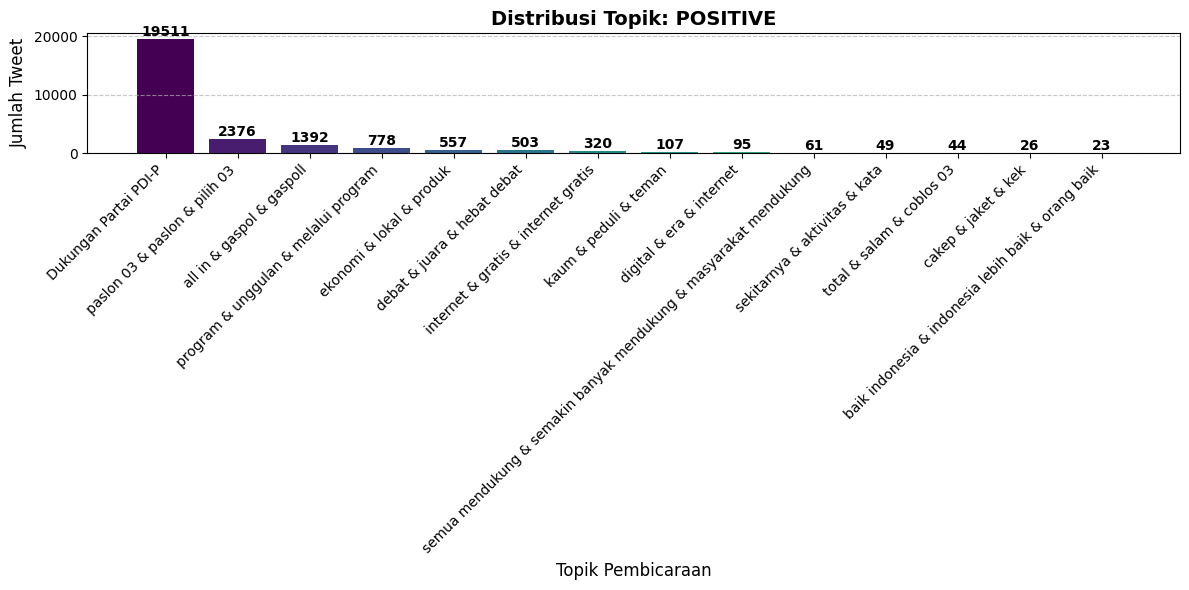

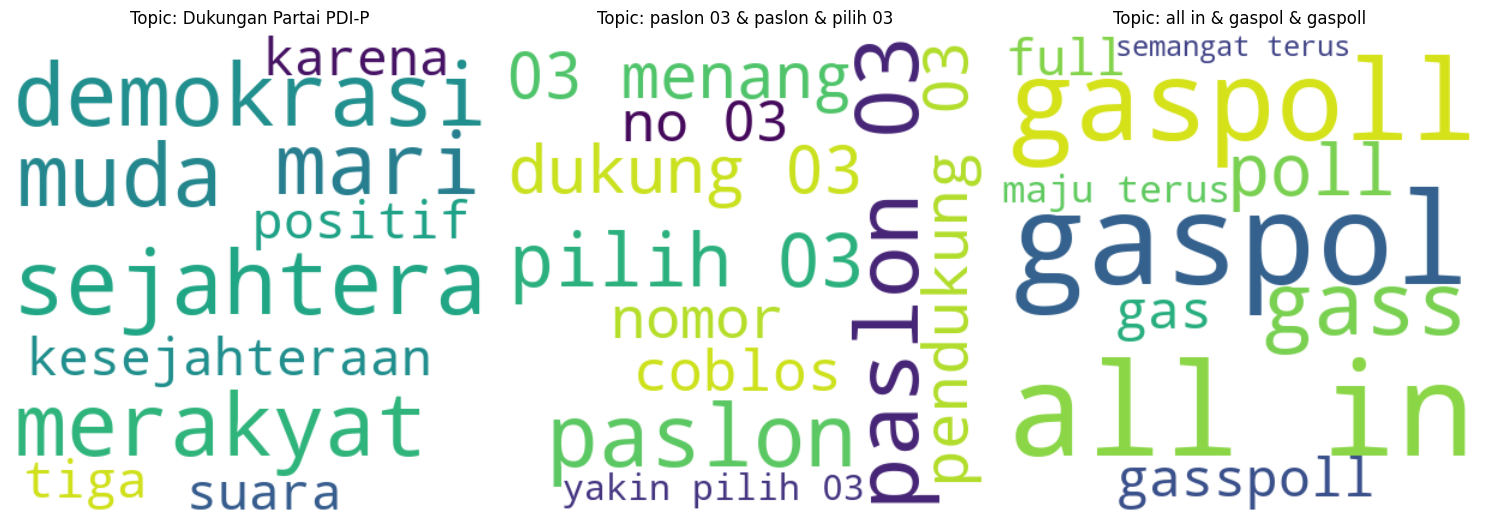


Kalimat Representatif untuk Setiap Topik (POSITIVE):


,Topic ID,Label,Representative Sentence
0,0,Dukungan Partai PDI-P,jangan biarkan kecurangan merusak proses demok...
1,1,paslon 03 & paslon & pilih 03,hentakan lagu salam m3tal bikin hati lebih man...
2,2,all in & gaspol & gaspoll,gaspoll pak ganjar mahfud all in ganjar mahfud
3,3,program & unggulan & melalui program,salut dengan program kerja pak ganjar mahfud s...
4,4,ekonomi & lokal & produk,kepemimpinan ganjar mahfud menciptakan momentu...
5,5,debat & juara & hebat debat,ganjar ahok jni formasi yang pas kayanya kalo ...
6,6,internet & gratis & internet gratis,internet gratis ganjar semangat pak untuk nega...
7,7,kaum & peduli & teman,angkie yudistia yang ikut serta dalam silatura...
8,8,digital & era & internet,ganjar dengan adanya internet gratis ganjar at...
9,9,semua mendukung & semakin banyak mendukung & m...,semakin banyak yang mendukung ganjar mahfud un...


(<bertopic._bertopic.BERTopic at 0x1d588386900>,
 [0,
  -1,
  -1,
  0,
  -1,
  0,
  0,
  0,
  0,
  -1,
  -1,
  2,
  0,
  3,
  -1,
  0,
  -1,
  -1,
  0,
  -1,
  0,
  0,
  0,
  -1,
  0,
  -1,
  0,
  0,
  0,
  -1,
  -1,
  0,
  -1,
  0,
  -1,
  -1,
  0,
  0,
  -1,
  -1,
  0,
  0,
  -1,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  -1,
  0,
  0,
  -1,
  -1,
  -1,
  -1,
  0,
  -1,
  0,
  0,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  -1,
  -1,
  0,
  0,
  0,
  2,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  -1,
  0,
  -1,
  0,
  0,
  -1,
  -1,
  0,
  -1,
  0,
  0,
  0,
  -1,
  0,
  0,
  -1,
  -1,
  0,
  -1,
  -1,
  0,
  0,
  -1,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  -1,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  0,
  -1,
  0,
  0,
  -1,
  -1,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  -1,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  -1,
  0,


In [6]:
df_positive = df_03[df_03['predicted_label'] == 'POSITIVE']
run_topic_modeling(df_positive, group_name='POSITIVE')

2025-05-26 21:31:46,959 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 350/350 [02:40<00:00,  2.18it/s]
2025-05-26 21:34:27,322 - BERTopic - Embedding - Completed ✓
2025-05-26 21:34:27,323 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-26 21:34:34,285 - BERTopic - Dimensionality - Completed ✓
2025-05-26 21:34:34,288 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 21:34:53,061 - BERTopic - Cluster - Completed ✓
2025-05-26 21:34:53,065 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-05-26 21:34:54,265 - BERTopic - Representation - Completed ✓
2025-05-26 21:34:54,267 - BERTopic - Topic reduction - Reducing number of topics
2025-05-26 21:34:54,281 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 21:34:54,979 - BERTopic - Representation - Completed ✓
2025-05-26 21:34:54,983 - BERTopic - Topic reduction - Re


Topic Information for: NEGATIVE
   Topic  Count                                    Name  \
0     -1   4293          -1_pendukung 03_milih_pdip_mas   
1      0   3383           0_indonesia_pilpres_lain_suka   
2      1   1156             1_survey_kena_gue_paslon 03   
3      2   1088    2_03 03_03 menang_pendukung 03_suara   
4      3    718                3_presiden_dinasti_mk_jd   
5      4    156             4_debat_samsul_pas_terakhir   
6      5     86          5_program_berjalan_gaji_miskin   
7      6     68       6_strategi_proyek_posisi_nasional   
8      7     66  7_tabrak_belimbing sayur_belimbing_gua   
9      8     42             8_fokus_dehh_mending_pusing   

                             CustomName  \
0                               outlier   
1            indonesia & pilpres & lain   
2                   survey & kena & gue   
3      03 03 & 03 menang & pendukung 03   
4               presiden & dinasti & mk   
5                  debat & samsul & pas   
6             pr

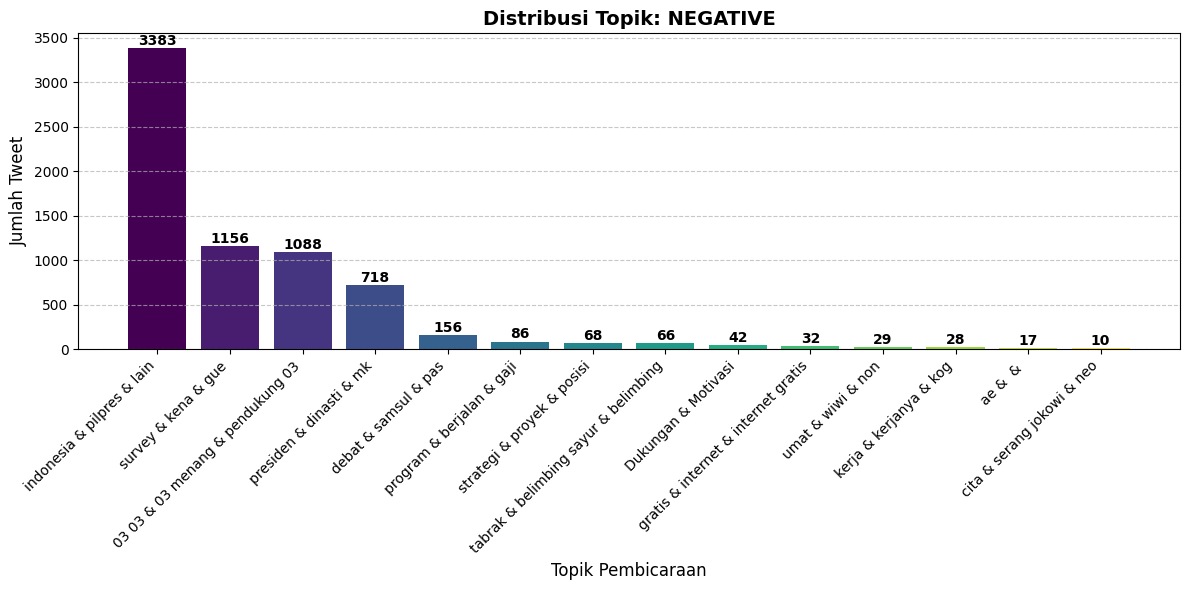

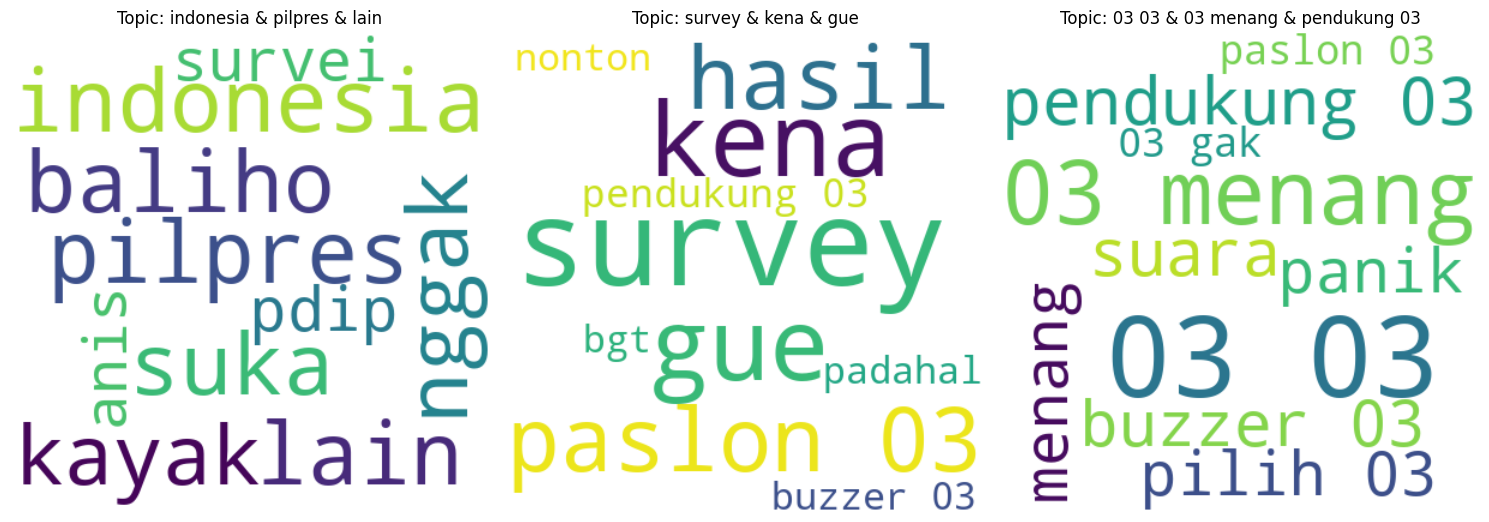


Kalimat Representatif untuk Setiap Topik (NEGATIVE):


,Topic ID,Label,Representative Sentence
0,0,indonesia & pilpres & lain,ya udah ga usah di pilih kalo begitu kan belum...
1,1,survey & kena & gue,ini blunder nyata dari pihak prabowo dan jauh ...
2,2,03 03 & 03 menang & pendukung 03,kalah disurai menang kampanye dipemilu pasti p...
3,3,presiden & dinasti & mk,awal ganjar tampak mampu jadi presiden ri lalu...
4,4,debat & samsul & pas,dasar bajer kalap tu kubu 03 alihkan isu krn p...
5,5,program & berjalan & gaji,wis angell angell opo sih abote milih 03 jelas...
6,6,strategi & proyek & posisi,pertama tidak memiliki positioning yg jelas ta...
7,7,tabrak & belimbing sayur & belimbing,anda sadis bro kasihan buzzer pak ganjar malam...
8,8,Dukungan & Motivasi,udah deh huru hara sana sini fokus ganjar mahf...
9,9,gratis & internet & internet gratis,ganjar kata kata yg dibilang prabowo ada di yt...


(<bertopic._bertopic.BERTopic at 0x1d5adf0c410>,
 [-1,
  0,
  0,
  -1,
  0,
  0,
  3,
  -1,
  0,
  -1,
  -1,
  0,
  -1,
  3,
  3,
  -1,
  0,
  -1,
  -1,
  4,
  -1,
  0,
  -1,
  -1,
  3,
  0,
  0,
  -1,
  -1,
  0,
  0,
  -1,
  0,
  0,
  0,
  -1,
  -1,
  -1,
  0,
  0,
  1,
  -1,
  0,
  0,
  0,
  0,
  -1,
  0,
  -1,
  0,
  0,
  -1,
  0,
  -1,
  1,
  -1,
  3,
  -1,
  0,
  -1,
  0,
  -1,
  0,
  -1,
  -1,
  -1,
  0,
  3,
  -1,
  -1,
  -1,
  0,
  -1,
  0,
  0,
  -1,
  0,
  3,
  3,
  0,
  -1,
  8,
  0,
  -1,
  0,
  8,
  -1,
  -1,
  0,
  0,
  -1,
  0,
  -1,
  0,
  -1,
  0,
  -1,
  -1,
  3,
  3,
  -1,
  0,
  0,
  0,
  0,
  3,
  11,
  0,
  0,
  3,
  -1,
  -1,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  -1,
  0,
  0,
  -1,
  0,
  -1,
  -1,
  3,
  0,
  0,
  1,
  0,
  0,
  0,
  -1,
  -1,
  0,
  0,
  -1,
  3,
  -1,
  3,
  0,
  -1,
  -1,
  0,
  -1,
  0,
  -1,
  -1,
  -1,
  6,
  -1,
  0,
  -1,
  0,
  3,
  3,
  0,
  0,
  -1,
  -1,
  3,
  0,
  0,
  0,
  0,
  -1,
  0,
  3,
  -1,
  10,
  0,
  -1,
  3,
  -1,
  3,

In [7]:
df_negative = df_03[df_03['predicted_label'] == 'NEGATIVE']
run_topic_modeling(df_negative, group_name='NEGATIVE')

2025-05-26 21:34:59,991 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 295/295 [01:35<00:00,  3.07it/s]
2025-05-26 21:36:36,047 - BERTopic - Embedding - Completed ✓
2025-05-26 21:36:36,048 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-26 21:36:48,844 - BERTopic - Dimensionality - Completed ✓
2025-05-26 21:36:48,845 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 21:37:15,937 - BERTopic - Cluster - Completed ✓
2025-05-26 21:37:15,938 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-05-26 21:37:16,399 - BERTopic - Representation - Completed ✓
2025-05-26 21:37:16,399 - BERTopic - Topic reduction - Reducing number of topics
2025-05-26 21:37:16,412 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 21:37:16,706 - BERTopic - Representation - Completed ✓
2025-05-26 21:37:16,710 - BERTopic - Topic reduction - Re


Topic Information for: NEUTRAL
   Topic  Count                                               Name  \
0     -1   2525                        -1_paslon_apa_paslon 03_tim   
1      0   2604                     0_juara_kampanye_ekonomi_hebat   
2      1   2095                             1_all in_all_m3nang_in   
3      2   1187                 2_paslon 03_paslon_coblos_pilih 03   
4      3    460                     3_presiden_politik_calon_wakil   
5      4    243                   4_program_akses_pendidikan_kerja   
6      5    100                     5_tegas_tolak_pengamat_membela   
7      6     59  6_positif_menang satu_menang satu putaran_satu...   
8      7     50                  7_terobosan_ekonomi_massa_siapkan   
9      8     32                                    8_no_anis_pdip_   

                                    CustomName  \
0                                      outlier   
1                   juara & kampanye & ekonomi   
2                        all in & all & m3nang 

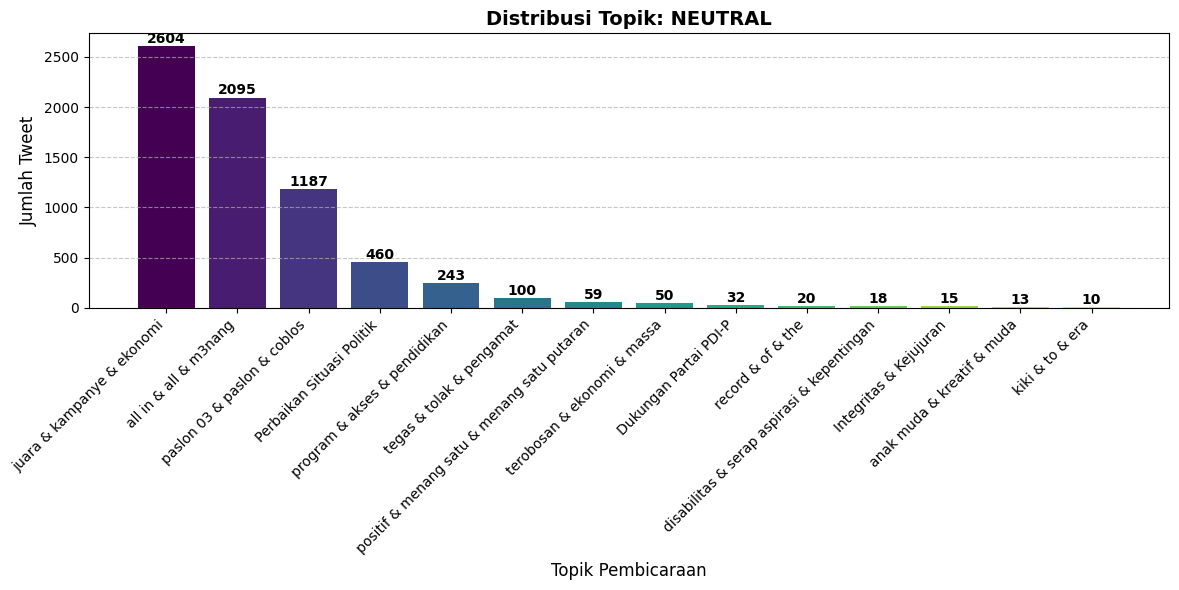

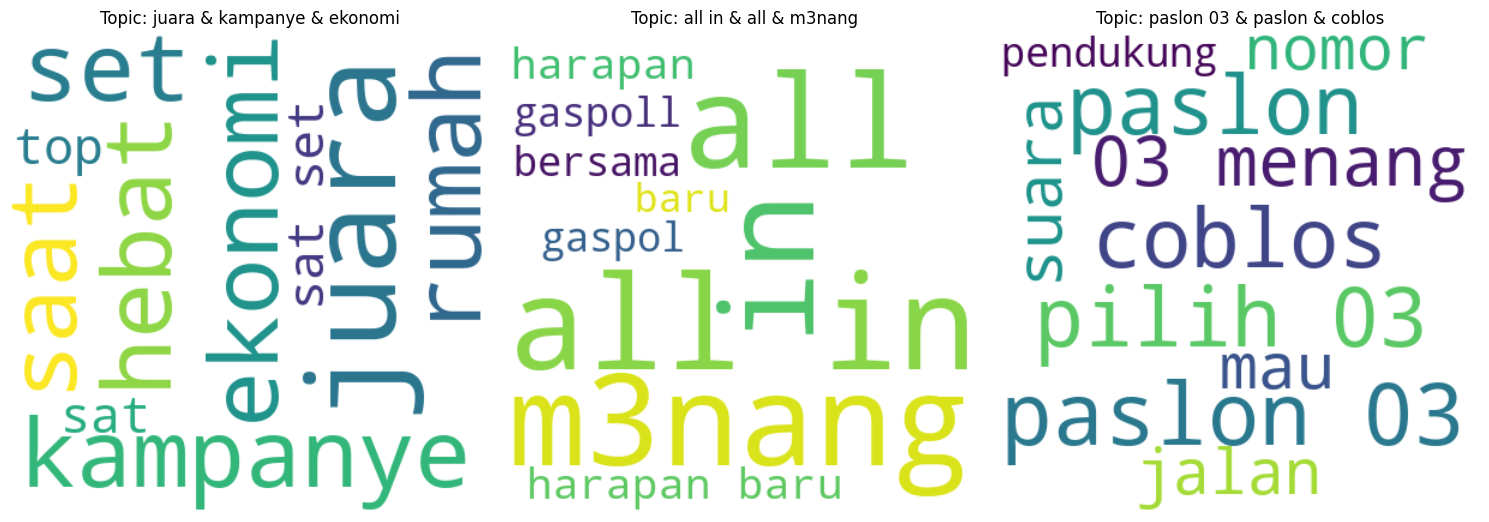


Kalimat Representatif untuk Setiap Topik (NEUTRAL):


,Topic ID,Label,Representative Sentence
0,0,juara & kampanye & ekonomi,ganjar mahfud merangkul visi inklusif dengan m...
1,1,all in & all & m3nang,gaspol dukung ganjar mahfud menang satu putaran
2,2,paslon 03 & paslon & coblos,mau gw post juga hasil gw dari paslon 03 dan p...
3,3,Perbaikan Situasi Politik,calon presiden nomor urut 03 ganjar pranowo ga...
4,4,program & akses & pendidikan,meski ganjar mahfud memiliki program nasional ...
5,5,tegas & tolak & pengamat,pengamat sebut ganjar capres paling tegas bela...
6,6,positif & menang satu & menang satu putaran,relawan ganjar dan mahfud optimis menang satu ...
7,7,terobosan & ekonomi & massa,pdi p mesin partainya masih bergerak solid ent...
8,8,Dukungan Partai PDI-P,prabowo yes ganjar yes anis no pdip no
9,9,record & of & the,ganjar ingin kembalikan kejayaan indonesia seb...


(<bertopic._bertopic.BERTopic at 0x1d5ad8120c0>,
 [0,
  1,
  0,
  1,
  1,
  1,
  0,
  -1,
  0,
  1,
  -1,
  0,
  -1,
  5,
  3,
  1,
  0,
  3,
  1,
  3,
  1,
  1,
  0,
  1,
  0,
  0,
  1,
  -1,
  3,
  -1,
  -1,
  1,
  0,
  -1,
  1,
  -1,
  3,
  1,
  -1,
  0,
  1,
  0,
  1,
  -1,
  3,
  11,
  0,
  0,
  0,
  -1,
  -1,
  -1,
  1,
  3,
  1,
  -1,
  -1,
  0,
  1,
  8,
  8,
  1,
  8,
  0,
  -1,
  -1,
  -1,
  8,
  1,
  1,
  0,
  8,
  8,
  1,
  -1,
  1,
  8,
  8,
  1,
  0,
  -1,
  1,
  0,
  -1,
  -1,
  0,
  0,
  -1,
  -1,
  -1,
  -1,
  1,
  1,
  1,
  1,
  1,
  8,
  8,
  0,
  3,
  1,
  1,
  0,
  -1,
  1,
  -1,
  0,
  3,
  -1,
  1,
  0,
  1,
  -1,
  0,
  1,
  1,
  3,
  1,
  1,
  -1,
  -1,
  3,
  -1,
  -1,
  -1,
  8,
  8,
  8,
  8,
  -1,
  3,
  8,
  8,
  8,
  8,
  0,
  8,
  8,
  8,
  8,
  -1,
  3,
  8,
  0,
  3,
  4,
  1,
  1,
  1,
  1,
  1,
  3,
  1,
  0,
  -1,
  8,
  1,
  8,
  8,
  0,
  0,
  8,
  8,
  8,
  3,
  1,
  8,
  8,
  4,
  -1,
  0,
  0,
  4,
  -1,
  -1,
  -1,
  -1,
  1,
  -1,
  4,
  0,
 

In [8]:
df_neutral = df_03[df_03['predicted_label'] == 'NEUTRAL']
run_topic_modeling(df_neutral, group_name='NEUTRAL')